# **Análisis frecuencial de señales**
## **Práctica 5 - Laboratorio de Bioseñales**
Luisa María Martínez Muelas

Carolina Taborda Vargas



#### **Resumen**

Las señales fisiológicas como el ECG y el EEG contienen información distribuida en distintas bandas de frecuencia que no es visible en el dominio del tiempo. Para analizarlas, deben digitalizarse respetando el teorema de Nyquist-Shannon, que establece que la frecuencia de muestreo debe ser al menos el doble de la frecuencia máxima de la señal, evitando así el aliasing. Una vez digitalizadas, se aplica la Transformada Discreta de Fourier (DFT), calculada eficientemente mediante el algoritmo FFT, para obtener su espectro de frecuencias. Para señales de larga duración, el método de Welch mejora la estimación espectral dividiendo la señal en segmentos solapados y promediando sus periodogramas, reduciendo la varianza y la fuga espectral mediante ventanas como la de Hanning. Con base en estos fundamentos, esta práctica busca implementar dichas herramientas en Python para analizar señales discretas, calcular sus propiedades energéticas y aplicar el análisis espectral sobre señales biomédicas reales [1][2].

In [13]:
#Librerías
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as io
from scipy.fft import fft, ifft, fftfreq
from scipy.signal import welch

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
#Exploración de datos
data=io.loadmat('senecg.mat')
display(data)

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Tue Dec 01 10:48:54 2015',
 '__version__': '1.0',
 '__globals__': [],
 'ECG': array([[ 0.16479384],
        [-0.00455636],
        [-0.23589197],
        ...,
        [ 0.00518452],
        [-0.18447972],
        [ 0.015     ]])}

##### **4.1. Señal de tres componentes sinusoidales**
Con frecuencias de 40, 80 y 160 Hz.

Fmax=160Hz

Fmin=40Hz

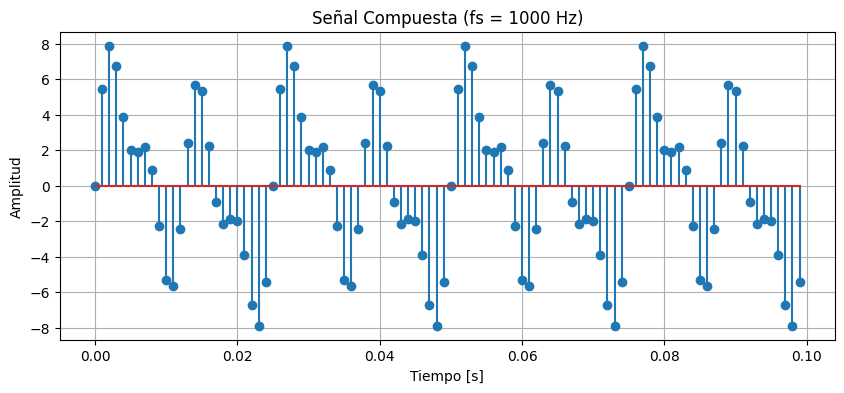

In [16]:
# Parámetros de la señal
fs = 1000 #se trabajó con más del doble de la frecuencia de muestreo, ya que al analizar los otros puntos del código, la frecuencia máxima
#no estaba presente en el espectro de la transformada de Fourier, por lo que aseguramos más del doble de la frecuencia.
t_final = 0.1
t = np.arange(0, t_final, 1/fs) # Vector de tiempo

# Componentes sinusoidales
f1, f2, f3 = 40, 80, 160
x = 2*np.sin(2 * np.pi * f1 * t) + 5*np.sin(2 * np.pi * f2 * t) + 3*np.sin(2 * np.pi * f3 * t)

# Graficación
plt.figure(figsize=(10, 4))
plt.stem(t, x)
plt.title(f"Señal Compuesta (fs = {fs} Hz)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()

La gráfica muestra la señal compuesta en el dominio del tiempo, muestreada a 320 Hz. Se observan las muestras discretas de la suma de las tres componentes sinusoidales (40, 80 y 160 Hz), donde la amplitud varía entre aproximadamente -6.5 y 6.5 V, resultado de la superposición de las tres sinusoidales. La frecuencia de muestreo de 320 Hz corresponde al doble de la frecuencia máxima presente en la señal (160 Hz), cumpliendo así con el criterio mínimo del teorema de Nyquist-Shannon para una representación fiel de la señal.

##### **4.2. Transformada de Fourier de la señal**

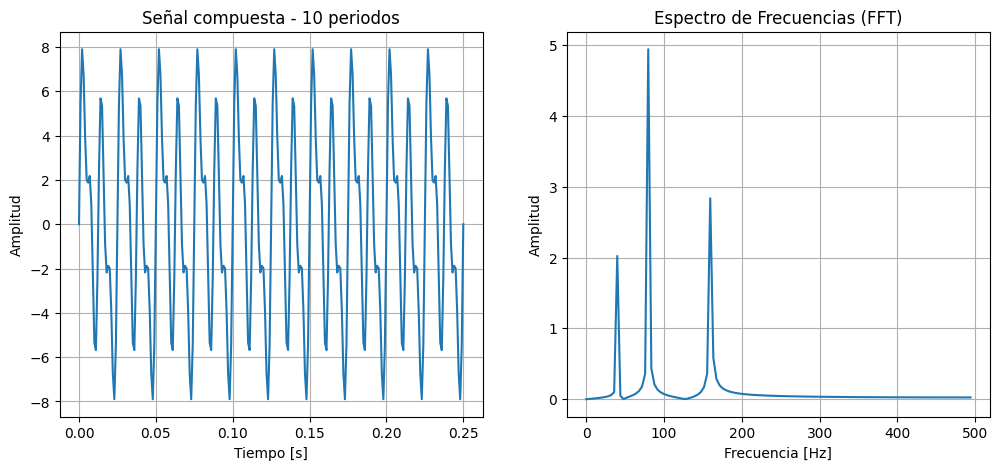

In [17]:

fs = 1000               # Frecuencia de muestreo
f_min = 40                   # Frecuencia más baja
T_total = 10 * (1/f_min)  #Aquí nos aseguramos de que trabajemos con la señal en 10 periodos
t = np.arange(0, T_total+1/fs, 1/fs)


x = 2*np.sin(2 * np.pi * f1 * t) + 5*np.sin(2 * np.pi * f2 * t) + 3*np.sin(2 * np.pi * f3 * t)

# Transformada de Fourier (FFT)
N = len(t)                   # Número de muestras
yf = fft(x)                  # Transformada
xf = fftfreq(N, 1/fs)        # Vector de frecuencias

# Aquí solo tomaremos la parte positiva del espectro que será la de nuestro interés
xf_pos = xf[:N//2]
yf_mag = (2.0/N) * np.abs(yf[:N//2])

# Gráfica
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(t, x)
plt.title("Señal compuesta - 10 periodos")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)

#Subplot para la transformada de fourier
plt.subplot(1, 2, 2)
plt.plot(xf_pos, yf_mag)
plt.title("Espectro de Frecuencias (FFT)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Amplitud")
plt.grid(True)


La señal compuesta muestra durante 10 periodos una forma de onda compleja resultado de la suma entre sus tres componentes sinusoidales. En el espectro de frecuencias se identifican claramente tres picos ubicados exactamente en las frecuencias que conforman la señal, confirmando que la FFT logra descomponer correctamente la señal en sus componentes frecuenciales individuales.

##### **Espectro de frecuencia**

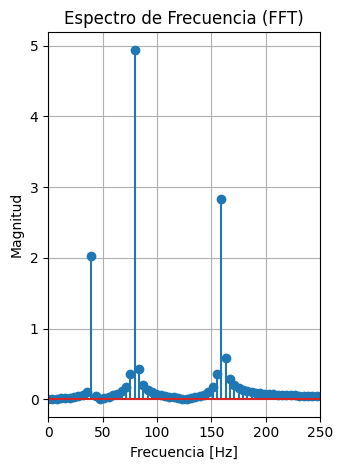

In [18]:
# Espectro de frecuencia
plt.subplot(1, 2, 2)
plt.stem(xf_pos, yf_mag)
plt.title("Espectro de Frecuencia (FFT)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.xlim(0, 250)
plt.grid(True)

plt.tight_layout()
plt.show()

Los tres picos se ubican claramente en las frecuencias esperadas de la señal, destacando el de 80 Hz como el de mayor magnitud, debido a la amplitud que se le dio a esta señal en la primera parte. Alrededor de cada pico se observa algo de ruido espectral, lo cual es normal dado que la señal no tiene una duración infinita, fenómeno conocido como fuga espectral. Por fuera de las frecuencias de interés el espectro se mantiene prácticamente en cero.

##### **4.3 Función para el cálculo de la transformada inversa de Fourier**

La transformada inversa de Fourier permite recuperar una señal en el dominio del tiempo a partir de su representación en el dominio de la frecuencia. En Python, la función ifft de la librería scipy.fft realiza este cálculo de manera eficiente. A continuación se aplica sobre la señal compuesta obtenida anteriormente para verificar que la reconstrucción es idéntica a la señal original [3].

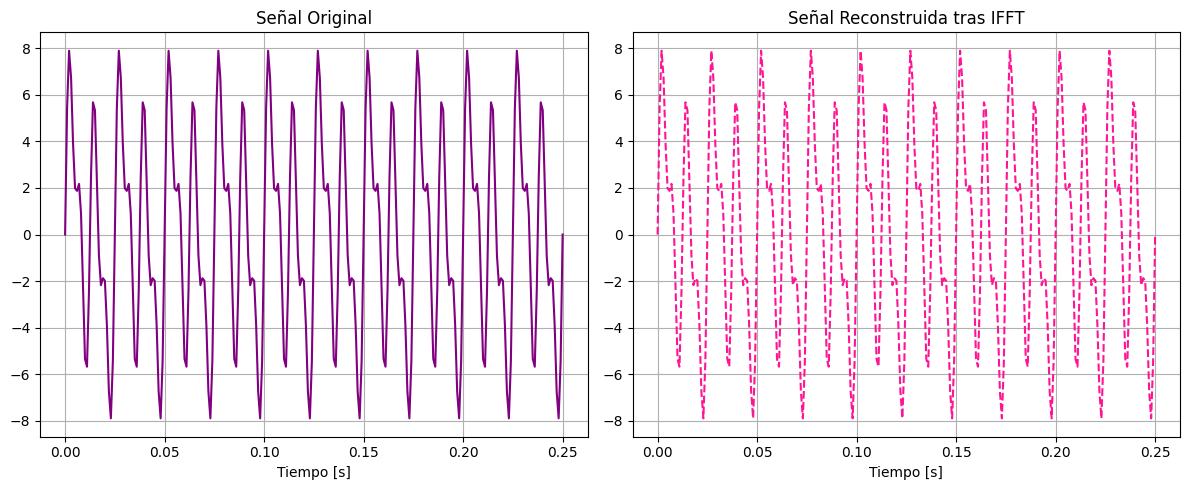

In [19]:
from scipy.fft import ifft

# yf es el vector complejo obtenido en el paso anterior con la función de la transformada de Fourier fft
x_reconstruida = ifft(yf)

# Gráfica
plt.figure(figsize=(12, 5))

# Señal Original
plt.subplot(1, 2, 1)
plt.plot(t, x, color='purple')
plt.title("Señal Original")
plt.xlabel("Tiempo [s]")
plt.grid(True)

# Señal Reconstruida
plt.subplot(1, 2, 2)
plt.plot(t, x_reconstruida.real, color='deeppink', linestyle='--')
plt.title("Señal Reconstruida tras IFFT")
plt.xlabel("Tiempo [s]")
plt.grid(True)

plt.tight_layout()
plt.show()

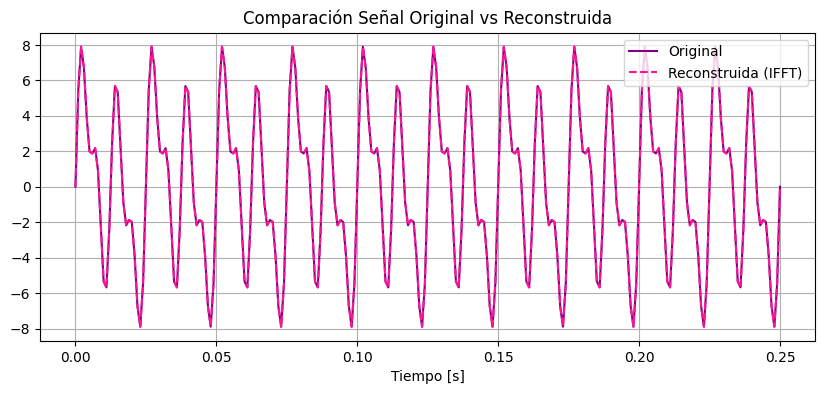

In [20]:
plt.figure(figsize=(10, 4))
plt.plot(t, x, color='purple', label='Original')
plt.plot(t, x_reconstruida.real, color='deeppink', linestyle='--', label='Reconstruida (IFFT)')
plt.title("Comparación Señal Original vs Reconstruida")
plt.xlabel("Tiempo [s]")
plt.legend()
plt.grid(True)
plt.show()

Ambas gráficas muestran la misma forma de onda con idénticas amplitudes y comportamiento temporal, confirmando que la IFFT reconstruyó la señal original de manera exacta. Esto era lo esperado, ya que la transformada inversa de Fourier es el proceso matemático opuesto a la FFT, permitiendo recuperar la señal en el dominio del tiempo a partir de su representación frecuencial sin pérdida de información.

### **4.4 ¿Las siguientes líneas aplican un filtro?**

/tmp/ipykernel_1876/1999882683.py:3: ComplexWarning: Casting complex values to real discards the imaginary part
  F2[9:13] = F1[9:13];


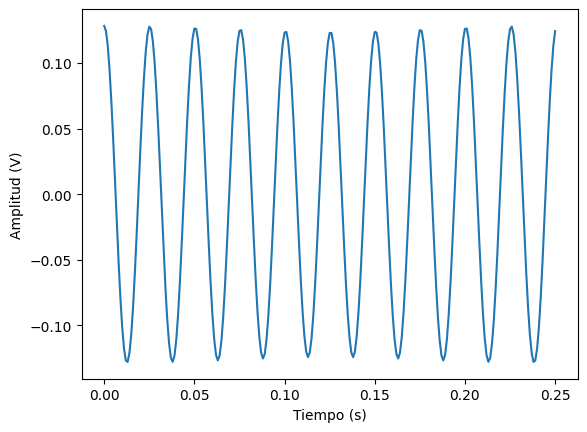

In [21]:
F1 = np.fft.fft(x);
F2 = np.zeros((len(F1)));
F2[9:13] = F1[9:13];

xr = np.fft.ifft(F2);

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(t, np.real(xr))

ax.set(xlabel='Tiempo (s)', ylabel='Amplitud (V)');
plt.show()

La señal con la que estamos trabajando se creó originalmente sumando tres frecuencias diferentes: de 40 Hz, 80 Hz y una 160 Hz. Al aplicar la Transformada de Fourier, la señal se desarma y pasa de ser una línea en el tiempo a convertirse en un mapa de frecuencias dividido.

Al calcular la relación entre los datos de nuestro código, el tamaño de la muestra y la velocidad de muestreo, descubrimos que la caja número 10 corresponde exactamente a la onda de 40 Hz.

$\text{Frecuencia} = \frac{\text{Número de caja} \times \text{Frecuencia de muestreo (Fs)}}{\text{Cantidad total de datos (N)}}$

Reemplazando:

$\text{Frecuencia} = \frac{10 \times 1000}{250} = \frac{10000}{250} = \mathbf{40\text{ Hz}}$

Por lo tanto, cuando el código ordena borrar todo y quedarse únicamente con las cajas de la 9 a la 12 (F2[9:13] = F1[9:13]), lo que está haciendo en realidad es un filtro que deja pasar la señal de 40 Hz y elimina por completo las de 80 Hz y 160 Hz. Es por esto que, al final del proceso, la señal que recuperamos vuelve a ser una onda limpia de 40 Hz.

/tmp/ipykernel_1876/660989128.py:4: ComplexWarning: Casting complex values to real discards the imaginary part
  F2[238:242] = F1[238:242]


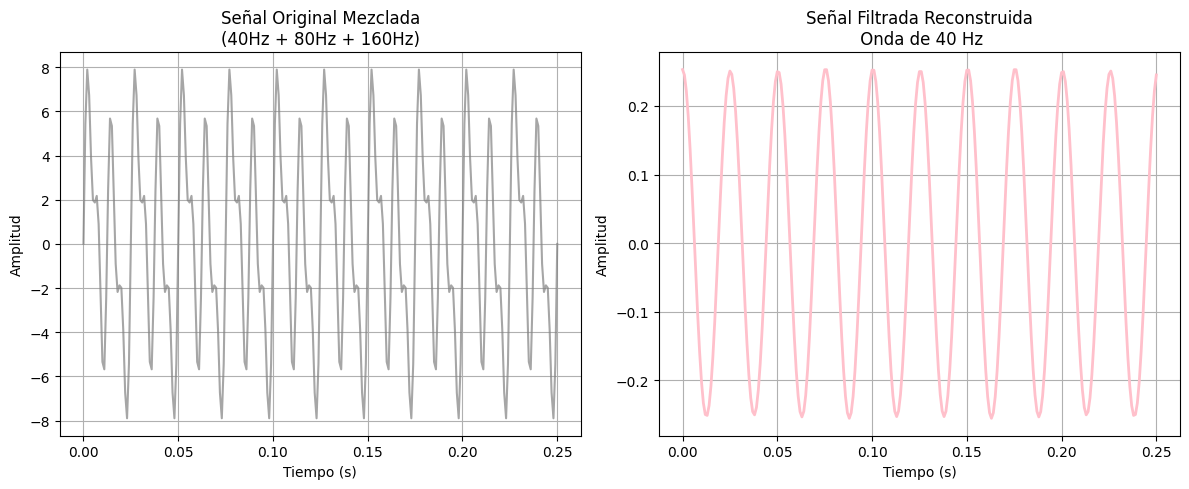

In [23]:
# Para que la señal vuelva a ser real en el tiempo,
# debemos conservar también el "espejo" del lado negativo de la FFT.
# La caja espejo de la 10 es (N - 10) = 240. Tomamos de la 238 a la 241.
F2[238:242] = F1[238:242]

x_filtrada = np.fft.ifft(F2)

plt.figure(figsize=(12, 5))

# Gráfica de la señal original
plt.subplot(1, 2, 1)
plt.plot(t, x, color='gray', alpha=0.7)
plt.title('Señal Original Mezclada\n(40Hz + 80Hz + 160Hz)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)

# Gráfica de la señal resultado del filtro
plt.subplot(1, 2, 2)
# Usamos np.real() porque la IFFT siempre devuelve una parte imaginaria matemática diminuta (casi cero)
plt.plot(t, np.real(x_filtrada), color='pink', linewidth=2)
plt.title('Señal Filtrada Reconstruida\n Onda de 40 Hz')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)

plt.tight_layout()
plt.show()

### **4.5 Análisis en frecuencia de la señal usando periodogramas de Welch**

(0.0, 100.0)

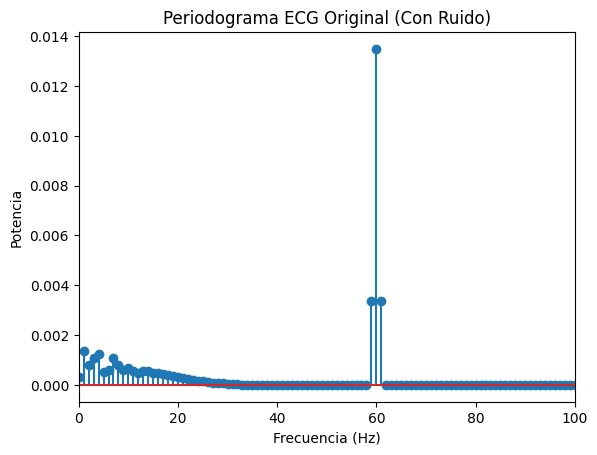

In [24]:
import scipy.io as sio
from scipy.signal import welch as pwelch

# 1. Cargar señal
mat_contents = sio.loadmat('senecg.mat')

# Inspecciona las llaves con mat_contents.keys() para hallar el nombre exacto de la variable
senal_ecg = mat_contents['ECG'].flatten()
fs_ecg = 250
N_ecg = len(senal_ecg)

# 2. Configurar Welch
nperseg = 250
noverlap = int(nperseg / 2)

# Periodograma Original
f_orig, Pxx_orig = pwelch(senal_ecg, fs_ecg, window='hann', nperseg=nperseg, noverlap=noverlap)


plt.stem(f_orig, Pxx_orig)
plt.title('Periodograma ECG Original (Con Ruido)')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Potencia')
plt.xlim([0, 100])


A partir del espectro de potencia obtenido mediante el método de Welch para la señal de ECG original, se confirma la presencia de ruido por interferencia eléctrica localizado exactamente en los 60 Hz. Como se puede observar en la gráfica, existe un pico de gran amplitud, agudo y aislado que sobresale de manera atípica respecto a los componentes normales de la señal. Este comportamiento es característico del ruido de línea o acoplamiento eléctrico proveniente de la red de energía de los equipos de adquisición, el cual concentra una enorme cantidad de potencia en esa frecuencia específica y justifica plenamente la necesidad de aplicar un método de filtrado para limpiar la señal.

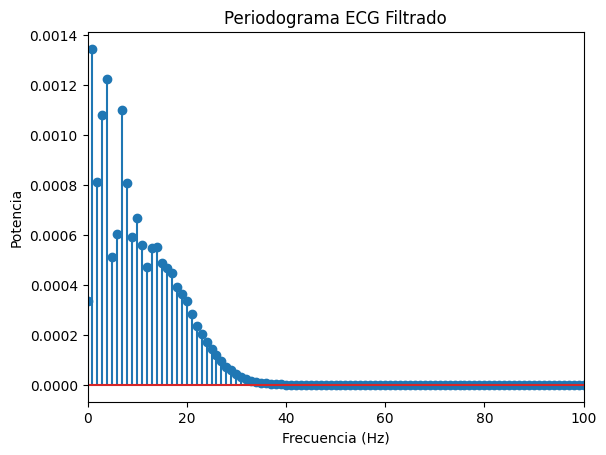

In [25]:
# 3. Filtrado mediante DFT (Eliminar el ruido identificado 60Hz)
F_ecg = np.fft.fft(senal_ecg)
freqs_fft = np.fft.fftfreq(N_ecg, d=1/fs_ecg) # Vector de frecuencias de la FFT

ruido_f = 60
tolerancia = 2 # Hz
mascara_ruido = (abs(freqs_fft) >= ruido_f - tolerancia) & (abs(freqs_fft) <= ruido_f + tolerancia)

F_ecg_filtrado = F_ecg.copy()
F_ecg_filtrado[mascara_ruido] = 0 # Apagamos las frecuencias de ruido

# 4. Reconstrucción en el tiempo
ecg_filtrado_tiempo = np.real(np.fft.ifft(F_ecg_filtrado))

# 5. Periodograma de la señal filtrada
f_filt, Pxx_filt = pwelch(ecg_filtrado_tiempo, fs_ecg, window='hann', nperseg=nperseg, noverlap=noverlap)

plt.stem(f_filt, Pxx_filt)

plt.title('Periodograma ECG Filtrado')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Potencia')
plt.xlim([0, 100])
plt.show()

Al comparar ambos periodogramas, se evidencia el efecto del filtro diseñado en el dominio de la frecuencia para limpiar la señal de ECG. En la gráfica de la señal original, se observa un pico de potencia extremadamente alto y aislado en los 60 Hz, el cual representa la interferencia eléctrica de la red y distorsiona el registro biomédico. Por el contrario, en la gráfica de la señal filtrada, se demuestra que dicho componente ruidoso fue eliminado por completo, permitiendo que el eje Y se reajuste automáticamente a una escala mucho menor  para revelar los componentes reales y atenuados de la señal. Este resultado confirma que el proceso de filtrado cumple con su objetivo de eliminar la contaminación por ruido de 60 Hz sin alterar el resto del espectro frecuencial del ECG.

### **4.6 Análisis de fecuencia con el periodograma de welch de una señal EEG de un paciente sano y un apciente con Parkinson**

In [1]:
!pip install mne

In [26]:
#CONECTAR DRIVE Y DESCOMPRIMIR EL ZIP (Para el paciente Parkinson)
from google.colab import drive
import os
import glob
import mne
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

drive.mount("/content/drive", force_remount=True)

ruta_zip = "/content/drive/MyDrive/datos_senales_datos_parkinson_cursos.zip"
!unzip -q "$ruta_zip" -d /content/datos_eeg/

print("Drive conectado y archivo ZIP descomprimido con éxito")

Mounted at /content/drive
replace /content/datos_eeg/control/C001R_EP_reposo.mat? [y]es, [n]o, [A]ll, [N]one, [r]ename: Drive conectado y archivo ZIP descomprimido con éxito


Archivo Sano (HC) listo: /content/sub-001_task-motion_run-10_eeg.set
Archivo Parkinson (PD) encontrado: /content/datos_eeg/parkinson/P018_EP_reposo.mat



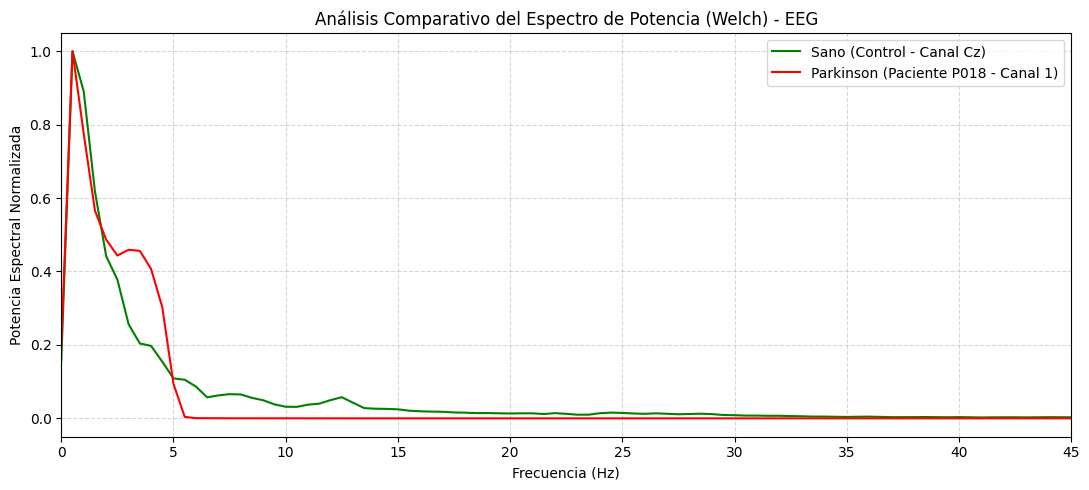

In [27]:
from scipy.signal import welch

# 1. DEFINIR LAS RUTAS DE LOS ARCHIVOS
ruta_sano = "/content/sub-001_task-motion_run-10_eeg.set"
archivos_mat = glob.glob("/content/datos_eeg/parkinson/*.mat")

if len(archivos_mat) == 0:
    archivos_mat = glob.glob("/content/datos_eeg/**/[pP]arkinson/*.mat", recursive=True)

if len(archivos_mat) == 0:
    print("Error: No se encontraron archivos .mat en la carpeta parkinson.")
else:
    # Usaremos el archivo P018_EP_reposo.mat o el primero disponible
    ruta_parkinson = archivos_mat[0]
    print(f"Archivo Sano (HC) listo: {ruta_sano}")
    print(f"Archivo Parkinson (PD) encontrado: {ruta_parkinson}\n")

    # 2. CARGAR Y PROCESAR EL PACIENTE SANO
    raw_sano = mne.io.read_raw_eeglab(ruta_sano, preload=True)
    fs_sano = int(raw_sano.info['sfreq'])

    # Extraemos el canal 'Cz'
    canal_sano = 'Cz'
    eeg_sano_data = raw_sano.get_data(picks=[canal_sano])[0]

    # 3. CARGAR Y REESTRUCTURAR EL PACIENTE PARKINSON (SciPy - .mat tridimensional)
    mat_contents = sio.loadmat(ruta_parkinson)
    matriz_3d = mat_contents['data'] # Forma: (8, 2000, 149)

    # Seleccionamos el primer canal disponible (Índice 0)
    # y usamos .flatten(order='F') para unir linealmente las 149 épocas una tras otra
    canal_pd_3d = matriz_3d[0, :, :] # Extrae forma (2000, 149)
    eeg_pd_data = canal_pd_3d.flatten(order='F') # Señal continua de 2000 * 149 muestras

    # Asumiremos la misma frecuencia de muestreo base para la comparación espectral
    fs_pd = fs_sano

    # 4. CÁLCULO DEL PERIODOGRAMA DE WELCH (Punto 4.6)
    # Parámetro de resolución: Ventana de 2 segundos para saltos limpios de 0.5 Hz
    nperseg_sano = fs_sano * 2
    noverlap_sano = nperseg_sano // 2

    nperseg_pd = fs_pd * 2
    noverlap_pd = nperseg_pd // 2

    f_hc, Pxx_hc = welch(eeg_sano_data, fs_sano, window='hann', nperseg=nperseg_sano, noverlap=noverlap_sano)
    f_pd, Pxx_pd = welch(eeg_pd_data, fs_pd, window='hann', nperseg=nperseg_pd, noverlap=noverlap_pd)

    # 5. GRAFICAR COMPARACIÓN DE DENSIDAD ESPECTRAL
    plt.figure(figsize=(11, 5))

    # Dividimos por el máximo para normalizar escalas debido a la diferencia estructural (.mat vs .set)
    plt.plot(f_hc, Pxx_hc / np.max(Pxx_hc), label='Sano (Control - Canal Cz)', color='green', linewidth=1.5)
    plt.plot(f_pd, Pxx_pd / np.max(Pxx_pd), label='Parkinson (Paciente P018 - Canal 1)', color='red', linewidth=1.5)

    plt.title('Análisis Comparativo del Espectro de Potencia (Welch) - EEG')
    plt.xlabel('Frecuencia (Hz)')
    plt.ylabel('Potencia Espectral Normalizada')

    # Rango de interés neurofisiológico clásico (0 a 45 Hz)
    plt.xlim([0, 45])
    plt.xticks(np.arange(0, 46, 5))
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

El análisis comparativo de la Densidad Espectral de Potencia (PSD) mediante el método de Welch permite evaluar la distribución de la energía de las señales de EEG en función de la frecuencia, facilitando la identificación de diferencias neurofisiológicas entre el sujeto de control (Sano) y el paciente con enfermedad de Parkinson.Se implementó una normalización de amplitud respecto al valor máximo de cada espectro. Esta estrategia asegura una comparación justa basada estrictamente en la morfología y distribución de las bandas de frecuencia, aislando sesgos por diferencias de ganancia.

Al examinar la curva del paciente con Parkinson (línea roja), se evidencia una concentración masiva de potencia en el extremo inferior del espectro, con un pico predominante entre los $0.5\text{ Hz}$ y los $4\text{ Hz}$, lo que corresponde a la banda de ondas lentas Delta. No obstante, el hallazgo más notorio en este perfil es la caída de la energía que ocurre inmediatamente después de los $5\text{ Hz}$, reduciendo la actividad espectral prácticamente a cero en el resto de las frecuencias evaluadas. Por otro lado, la respuesta espectral del sujeto sano (línea verde) muestra una transición mucho más suave, continua y fisiológicamente esperable a lo largo del rango evaluado ($0\text{ Hz}$ a $45\text{ Hz}$). Para este sujeto es posible identificar pequeñas ondulaciones y variaciones de potencia entre los $8\text{ Hz}$ y los $13\text{ Hz}$, asociadas habitualmente a los ritmos Alpha en estados de reposo o tareas motoras, así como actividad en la banda Beta, por encima de los $15\text{ Hz}$.


# Análisis fisiológico

Cuando un neurólogo analiza las ondas cerebrales de un paciente mediante un mapa cerebral, lo que busca es ver qué tan rápido o qué tan lento está trabajando el cerebro.

Si miramos la línea roja, que representa al paciente con Parkinson, vemos un comportamiento muy marcado, hay una cantidad de energía acumulada en las frecuencias más bajas (entre 0.5 y 4 Hz) y luego la línea cae a cero de forma drástica. En la medicina se sabe que el Parkinson frena el ritmo del cerebro. Al dañarse las neuronas que producen dopamina, el cerebro pierde el control de sus motores y empieza a generar ondas excesivamente lentas (llamadas ondas Delta).

Por el contrario, la línea verde del sujeto sano muestra cómo se comporta un cerebro saludable y activo. Aunque también tiene fuerza en las frecuencias bajas lo cual es normal al estar en reposo, su línea no se apaga, sino que continúa fluyendo con suavidad por todo el gráfico. En el sujeto sano podemos ver pequeñas curvas en las zonas de 8 a 12 Hz (ondas Alpha) y más adelante (ondas Beta). Médicamente, estas ondas rápidas son las que nos permiten pensar, movernos con precisión y reaccionar al entorno. Su presencia demuestra que las conexiones entre el centro del cerebro y la corteza están intactas y trabajando en perfecta armonía.

En conclusión, la gráfica nos muestra visualmente la gran diferencia entre la flexibilidad de ambos cerebros. El sujeto sano tiene una actividad equilibrada y conserva todas las frecuencias necesarias para el día a día. En cambio, el paciente con Parkinson muestra un espectro en las ondas lentas.

### **Conclusiones**

* Validación del Teorema de Nyquist-Shannon: Se demostró experimentalmente que para digitalizar y reconstruir correctamente las señales de ECG y EEG sin pérdida de información (aliasing), la frecuencia de muestreo ($f_s$) debe superar al menos el doble de la componente de frecuencia más alta contenida en la bioseñal.

* El análisis en el dominio del tiempo de una señal compuesta resulta insuficiente para caracterizarla, dado que la superposición de ondas enmascara la naturaleza individual de sus componentes. La implementación del algoritmo FFT demostró ser una herramienta indispensable que permite desacoplar de forma exacta las amplitudes y frecuencias constituyentes (40, 80 y 160 Hz), validando el principio fundamental de la descomposición de Fourier en señales discretas.

* Eficiencia en la Identificación: La Transformada Discreta de Fourier (DFT/FFT) demostró ser una herramienta matemática precisa para descomponer las bioseñales complejas y aislar las componentes sinusoidales elementales que no son visibles en el dominio del tiempo.

* Método de Welch en Bioseñales: Para registros de larga duración expuestos a ruido (como el EEG y ECG), el método de Welch optimizó la estimación espectral en comparación con el periodograma estándar, ya que el promediado de segmentos solapados y el uso de ventanas (como Hanning) redujeron la varianza.

* Detección Funcional de Patología: El análisis de la Densidad Espectral de Potencia (PSD) permitió contrastar de manera objetiva los ritmos cerebrales entre un sujeto sano y uno con Parkinson, consolidando al análisis frecuencial como un biomarcador clave para evaluar la pérdida de frecuencias rápidas (Alpha/Beta) en enfermedades neurodegenerativas.




##### **Referencias**

[1] Proakis, J. G., & Manolakis, D. G. (2007). Digital Signal Processing: Principles, Algorithms, and Applications (4th ed.). Prentice Hall. Disponible en: https://uvceee.wordpress.com/wp-content/uploads/2016/09/digital_signal_processing_principles_algorithms_and_applications_third_edition.pdf

[2] Oppenheim, A. V., & Schafer, R. W. (2010). Discrete-Time Signal Processing (3rd ed.). Pearson. Disponible en: https://api.pageplace.de/preview/DT0400.9781292038155_A24581738/preview-9781292038155_A24581738.pdf

[3] SciPy developers. (2024). scipy.fft — Discrete Fourier Transform. https://docs.scipy.org/doc/scipy/reference/fft.html